In [1]:

#NumPy Array Operations
import numpy as np

# Start with a matrix of ones
matrix = np.ones((5, 5), dtype=int)

# Set the interior (rows 1 to 3, columns 1 to 3) to zero
matrix[1:-1, 1:-1] = 0

print(matrix)

#Normalize a random array
import numpy as np

np.random.seed(42)
random_data = np.random.randn(100, 3)

# Normalize each column
normalized_data = (random_data - random_data.mean(axis=0)) / random_data.std(axis=0)

print(normalized_data.mean(axis=0))  # should be close to [0, 0, 0]
print(normalized_data.std(axis=0))   # should be close to [1, 1, 1]

#Implement linear regression solution using normal equation


import numpy as np

# Generate synthetic dataset
X = np.random.randn(50, 3)
true_theta = np.array([2.5, -1.2, 3.7])
y = X @ true_theta + np.random.randn(50) * 0.1  # add small noise

# Normal equation: theta_hat = (X^T X)^(-1) X^T y
XTX = X.T @ X
XTy = X.T @ y
theta_hat = np.linalg.inv(XTX) @ XTy

print("Estimated coefficients:", theta_hat)
print("True coefficients:", true_theta)





[[1 1 1 1 1]
 [1 0 0 0 1]
 [1 0 0 0 1]
 [1 0 0 0 1]
 [1 1 1 1 1]]
[-2.60902411e-17  1.55431223e-17 -8.88178420e-18]
[1. 1. 1.]
Estimated coefficients: [ 2.51723721 -1.19783796  3.72399266]
True coefficients: [ 2.5 -1.2  3.7]


In [3]:
"""
Exercise 5: Pandas Data Analysis
Analyze a dataset of student performance.
"""

import pandas as pd
import numpy as np

# Create sample dataset
np.random.seed(42)
n_students = 200

data = {
    'student_id': range(1000, 1000 + n_students),
    'major': np.random.choice(['CS', 'Math',
         'Physics', 'Biology'], n_students),
    'year': np.random.choice([1, 2, 3, 4], n_students),
    'exam_score': np.random.normal(75, 10, n_students).clip(0, 100),
    'assignments_completed': np.random.randint(0, 11, n_students),
    'hours_studied': np.random.normal(15, 5, n_students).clip(1, 40)
}

df = pd.DataFrame(data)

# Introduce some NaN values
df.loc[np.random.choice(n_students, 10), 'exam_score'] = np.nan
df.loc[np.random.choice(n_students, 5), 'hours_studied'] = np.nan
import pandas as pd

# Assume your dataset is loaded into a DataFrame called df
# Example: df = pd.read_csv("students.csv")

# 1. Display basic information about the dataset
print("Basic Info:")
print(df.info())
print("\nSummary Statistics:")
print(df.describe(include="all"))

# 2. Identify and count missing values
print("\nMissing Values:")
print(df.isnull().sum())

# 3. Fill missing exam_score with the mean score for the student's major
df['exam_score'] = df.groupby('major')['exam_score'].transform(
    lambda x: x.fillna(x.mean())
)

# 4. Fill missing hours_studied with the median for the student's year
df['hours_studied'] = df.groupby('year')['hours_studied'].transform(
    lambda x: x.fillna(x.median())
)

# Verify cleaning
print("\nAfter Cleaning:")
print(df.isnull().sum())

#Analysis
import pandas as pd

# Assume your cleaned dataset is in df

# 1. Calculate and display the average exam_score by major
avg_scores = df.groupby('major')['exam_score'].mean()
print("Average exam_score by major:\n", avg_scores)

# 2. Find the major with the highest average exam_score
top_major = avg_scores.idxmax()
top_score = avg_scores.max()
print(f"\nMajor with highest average exam_score: {top_major} ({top_score:.2f})")

# 3. Calculate the correlation between hours_studied and exam_score
correlation = df['hours_studied'].corr(df['exam_score'])
print(f"\nCorrelation between hours_studied and exam_score: {correlation:.3f}")

# 4. Create a new column 'performance' with categories
def categorize_performance(score):
    if score > 90:
        return 'Excellent'
    elif score >= 80:
        return 'Good'
    elif score >= 70:
        return 'Average'
    else:
        return 'Needs Improvement'

df['performance'] = df['exam_score'].apply(categorize_performance)

print("\nPerformance categories added:")
print(df[['exam_score', 'performance']].head())

# Advanced Analysis
import pandas as pd

# Assume your cleaned dataset is in df

# 1. For each major and year combination:
grouped_stats = df.groupby(['major', 'year']).agg(
    num_students=('exam_score', 'count'),
    avg_exam_score=('exam_score', 'mean'),
    avg_hours_studied=('hours_studied', 'mean')
).reset_index()

print("Stats by major and year:\n", grouped_stats)

# 2. Identify top 5 students based on exam_score (handle ties)
# Sort by exam_score descending, then use rank to handle ties
df['rank'] = df['exam_score'].rank(method='dense', ascending=False)
top_students = df[df['rank'] <= 5].sort_values(by=['exam_score', 'hours_studied'], ascending=[False, False])

print("\nTop 5 students (with ties handled):\n", top_students[['exam_score', 'hours_studied', 'major', 'year']])

# 3. Create a pivot table showing average exam_score by major (rows) and year (columns)
pivot_table = pd.pivot_table(
    df,
    values='exam_score',
    index='major',
    columns='year',
    aggfunc='mean'
)

print("\nPivot table of average exam_score by major and year:\n", pivot_table)






Basic Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             200 non-null    int64  
 1   major                  200 non-null    object 
 2   year                   200 non-null    int64  
 3   exam_score             190 non-null    float64
 4   assignments_completed  200 non-null    int64  
 5   hours_studied          195 non-null    float64
dtypes: float64(2), int64(3), object(1)
memory usage: 9.5+ KB
None

Summary Statistics:
         student_id    major        year  exam_score  assignments_completed  \
count    200.000000      200  200.000000  190.000000             200.000000   
unique          NaN        4         NaN         NaN                    NaN   
top             NaN  Physics         NaN         NaN                    NaN   
freq            NaN       54         NaN         NaN            

/tmp/ipykernel_1572/2160271901.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='major', y='exam_score', data=df, ax=axes[1], palette="Set2")


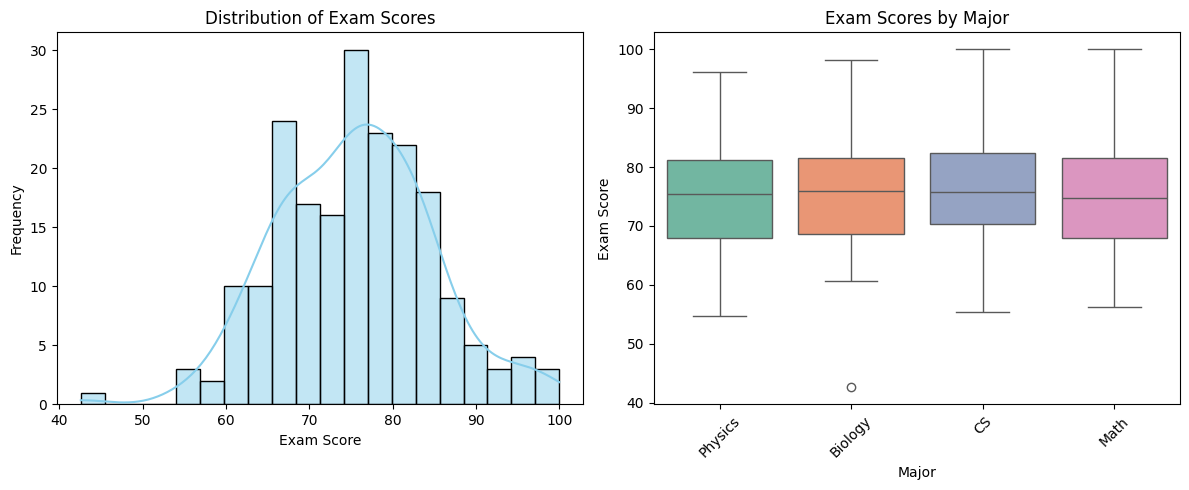

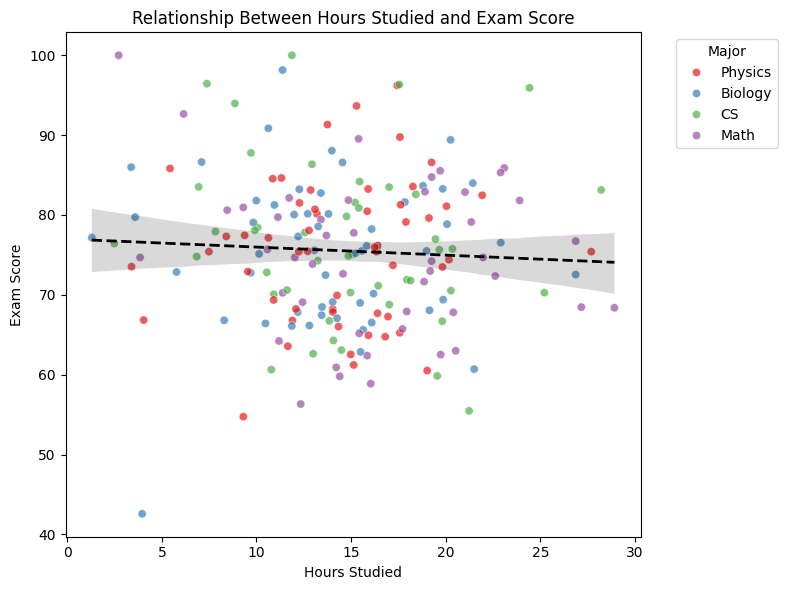

/tmp/ipykernel_1572/2160271901.py:84: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_scores.index, y=avg_scores.values, ax=axes[0,0], palette="Blues_d")
/tmp/ipykernel_1572/2160271901.py:91: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='year', data=df, ax=axes[0,1], palette="Set2")
/tmp/ipykernel_1572/2160271901.py:102: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='performance', y='exam_score', data=df, ax=axes[1,1], palette="Pastel1")


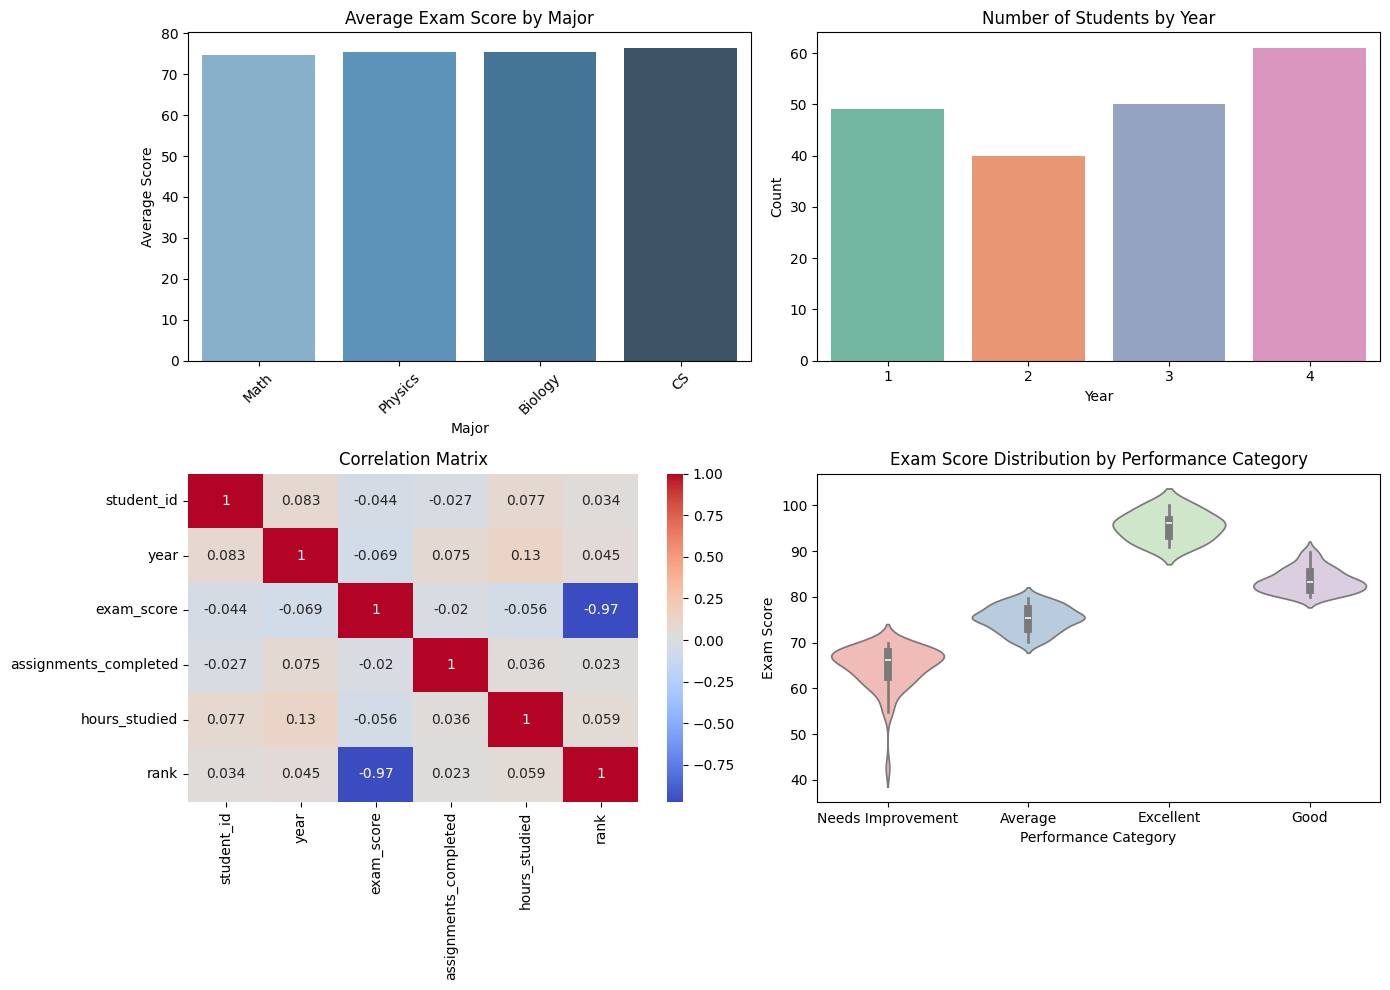

In [3]:
"""
Exercise 6: Data Visualization
Create meaningful visualizations using the dataset from Exercise 5.
"""

import matplotlib.pyplot as plt
import seaborn as sns


#Distribution Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Assume your cleaned dataset is in df

# Create figure with 2 subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: Histogram of exam scores with KDE overlay
sns.histplot(df['exam_score'], bins=20, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title("Distribution of Exam Scores")
axes[0].set_xlabel("Exam Score")
axes[0].set_ylabel("Frequency")

# Right: Box plot of exam scores by major
sns.boxplot(x='major', y='exam_score', data=df, ax=axes[1], palette="Set2")
axes[1].set_title("Exam Scores by Major")
axes[1].set_xlabel("Major")
axes[1].set_ylabel("Exam Score")
axes[1].tick_params(axis='x', rotation=45)  # rotate labels for readability

plt.tight_layout()
plt.show()

# Relationship Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Assume your cleaned dataset is in df

plt.figure(figsize=(8,6))

# Scatter plot of hours_studied vs exam_score, colored by major
sns.scatterplot(
    x='hours_studied',
    y='exam_score',
    hue='major',
    data=df,
    palette='Set1',
    alpha=0.7
)

# Add regression line (overall trend)
sns.regplot(
    x='hours_studied',
    y='exam_score',
    data=df,
    scatter=False,
    color='black',
    line_kws={'linewidth':2, 'linestyle':'--'}
)

# Titles and labels
plt.title("Relationship Between Hours Studied and Exam Score")
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.legend(title="Major", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

#Advanced Dashboard

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Assume your cleaned dataset is in df

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Bar chart: Average exam score by major
avg_scores = df.groupby('major')['exam_score'].mean().sort_values()
sns.barplot(x=avg_scores.index, y=avg_scores.values, ax=axes[0,0], palette="Blues_d")
axes[0,0].set_title("Average Exam Score by Major")
axes[0,0].set_xlabel("Major")
axes[0,0].set_ylabel("Average Score")
axes[0,0].tick_params(axis='x', rotation=45)

# 2. Count plot: Number of students by year
sns.countplot(x='year', data=df, ax=axes[0,1], palette="Set2")
axes[0,1].set_title("Number of Students by Year")
axes[0,1].set_xlabel("Year")
axes[0,1].set_ylabel("Count")

# 3. Heat map: Correlation matrix of numerical columns
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm", ax=axes[1,0])
axes[1,0].set_title("Correlation Matrix")

# 4. Violin plot: Exam score distribution by performance category
sns.violinplot(x='performance', y='exam_score', data=df, ax=axes[1,1], palette="Pastel1")
axes[1,1].set_title("Exam Score Distribution by Performance Category")
axes[1,1].set_xlabel("Performance Category")
axes[1,1].set_ylabel("Exam Score")

plt.tight_layout()
plt.show()




              age         income  purchase_frequency  avg_purchase_value
count  500.000000     500.000000          500.000000          500.000000
mean    44.220000   49710.497977            4.994000          100.689128
std     15.036082   19227.627832            2.352239           30.766169
min     18.000000   15000.000000            0.000000           20.773070
25%     32.000000   35715.092154            3.000000           78.937448
50%     45.000000   49549.733189            5.000000          101.523800
75%     57.000000   62573.326849            7.000000          122.418757
max     69.000000  111577.616169           12.000000          182.979388


/tmp/ipykernel_3044/3951535986.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='income_segment', y='income', data=customers, ax=axes[0,1], palette="Set2")


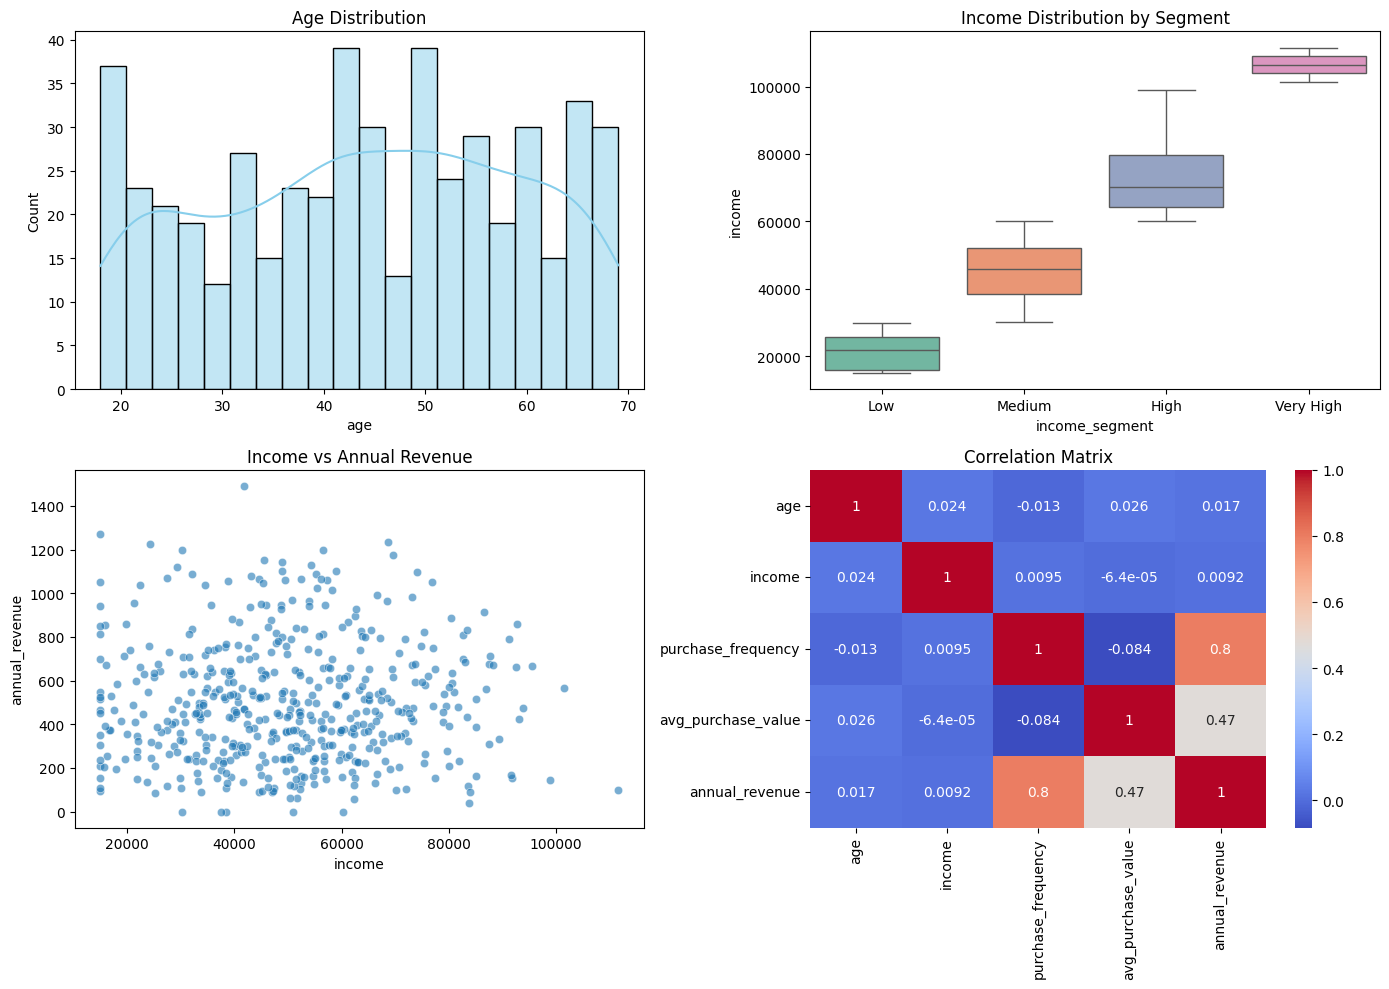

   purchase_frequency  avg_purchase_value  churn_risk          CLV
0                   7           94.527456    0.416667   937.397271
1                   2          100.932279    0.833333   370.085023
2                   3           79.699876    0.750000   418.424348
3                   2          130.137787    0.833333   477.171887
4                   8          102.904845    0.333333  1097.651683
   age age_group
0   56     51-70
1   69     51-70
2   46     36-50
3   32     26-35
4   60     51-70
5   25     18-25
6   38     36-50
7   56     51-70
8   36     36-50
9   40     36-50
  age_group  num_customers    avg_income     avg_CLV      total_CLV
0     18-25             81  50634.018330  718.371170   58188.064760
1     26-35             73  48747.148046  747.738562   54584.915035
2     36-50            160  48516.895668  732.796612  117247.457917
3     51-70            186  50713.163384  762.693498  141860.990683
Top 10% of customers by CLV:
     age        income  purchase_frequency

/tmp/ipykernel_3044/3951535986.py:116: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_group_stats = customers.groupby('age_group').agg(


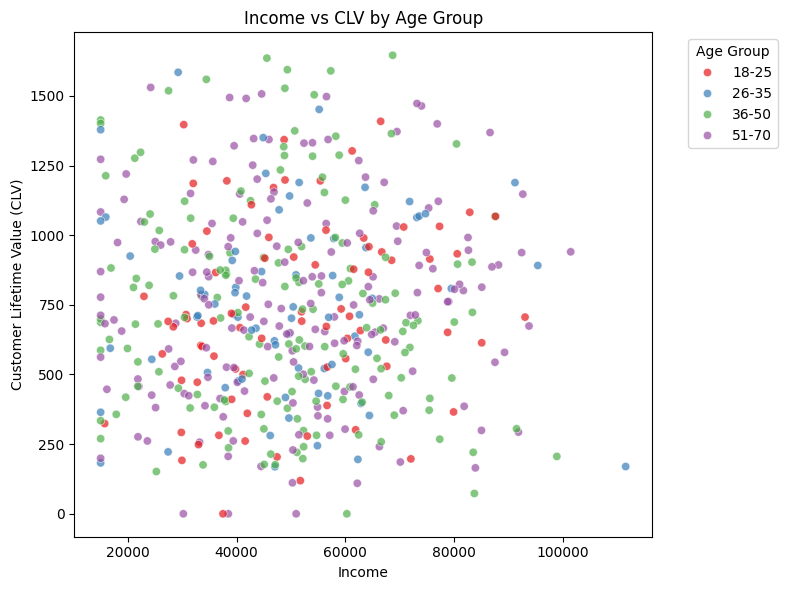

/tmp/ipykernel_3044/3951535986.py:162: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


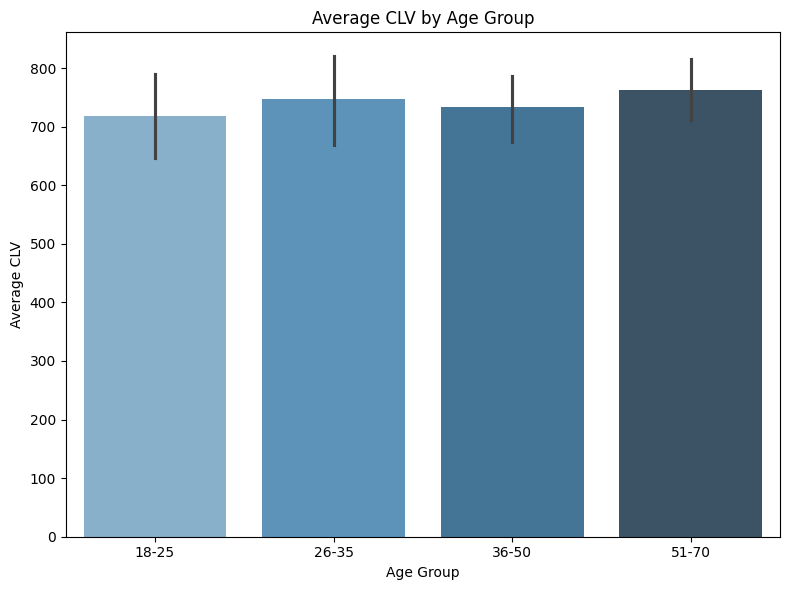

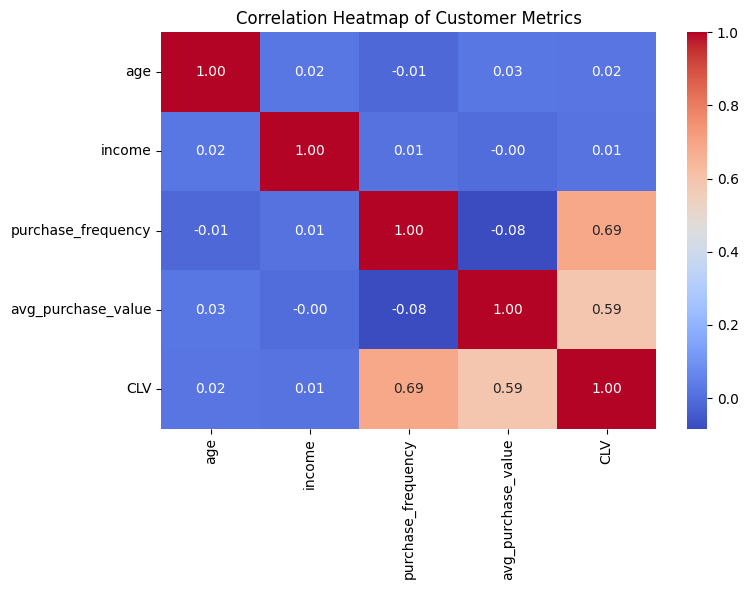

In [ ]:
"""
Exercise 7: Integration Challenge
Combine NumPy, Pandas, and Matplotlib to solve a mini data science problem.
"""

# Scenario: You're analyzing customer data for an e-commerce company.
# Generate synthetic data and provide insights.

np.random.seed(42)
n_customers = 500

# Generate customer data
ages = np.random.randint(18, 70, n_customers)
income = np.random.normal(50000, 20000, n_customers).clip(15000, 150000)
purchase_freq = np.random.poisson(5, n_customers)
avg_purchase_value = np.random.normal(100, 30, n_customers).clip(10, 500)

# Create DataFrame
customers = pd.DataFrame({
    'age': ages,
    'income': income,
    'purchase_frequency': purchase_freq,
    'avg_purchase_value': avg_purchase_value
})

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Synthetic data already created
np.random.seed(42)
n_customers = 500

ages = np.random.randint(18, 70, n_customers)
income = np.random.normal(50000, 20000, n_customers).clip(15000, 150000)
purchase_freq = np.random.poisson(5, n_customers)
avg_purchase_value = np.random.normal(100, 30, n_customers).clip(10, 500)

customers = pd.DataFrame({
    'age': ages,
    'income': income,
    'purchase_frequency': purchase_freq,
    'avg_purchase_value': avg_purchase_value
})

# --- Analysis ---

# 1. Basic info
print(customers.describe())

# 2. Total revenue per customer
customers['annual_revenue'] = customers['purchase_frequency'] * customers['avg_purchase_value']

# 3. Segment customers by income
customers['income_segment'] = pd.cut(customers['income'],
                                     bins=[0, 30000, 60000, 100000, 150000],
                                     labels=['Low', 'Medium', 'High', 'Very High'])

# --- Visualization Dashboard ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# A. Histogram of ages
sns.histplot(customers['age'], bins=20, kde=True, ax=axes[0,0], color='skyblue')
axes[0,0].set_title("Age Distribution")

# B. Boxplot of income by segment
sns.boxplot(x='income_segment', y='income', data=customers, ax=axes[0,1], palette="Set2")
axes[0,1].set_title("Income Distribution by Segment")

# C. Scatter plot: income vs annual revenue
sns.scatterplot(x='income', y='annual_revenue', data=customers, ax=axes[1,0], alpha=0.6)
axes[1,0].set_title("Income vs Annual Revenue")

# D. Heatmap of correlations
corr = customers[['age','income','purchase_frequency','avg_purchase_value','annual_revenue']].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", ax=axes[1,1])
axes[1,1].set_title("Correlation Matrix")

plt.tight_layout()
plt.show()

#Calculate customer lifetime value
# Calculate churn risk
max_frequency = customers['purchase_frequency'].max()
customers['churn_risk'] = 1 - (customers['purchase_frequency'] / max_frequency)

# Calculate CLV
customers['CLV'] = customers['purchase_frequency'] * customers['avg_purchase_value'] * (1 + customers['churn_risk'])

# Preview results
print(customers[['purchase_frequency', 'avg_purchase_value', 'churn_risk', 'CLV']].head())

# Create age groups
import pandas as pd

# Assume your DataFrame is called customers

# Define age bins and labels
age_bins = [18, 25, 35, 50, 70]
age_labels = ['18-25', '26-35', '36-50', '51-70']

# Create age_group column
customers['age_group'] = pd.cut(customers['age'], bins=age_bins, labels=age_labels, right=True, include_lowest=True)

# Preview results
print(customers[['age', 'age_group']].head(10))

#For each age group,

import pandas as pd

# Assume your DataFrame is called customers and already has 'age_group' column

# Group by age_group and calculate metrics
age_group_stats = customers.groupby('age_group').agg(
    num_customers=('age', 'count'),
    avg_income=('income', 'mean'),
    avg_CLV=('CLV', 'mean'),
    total_CLV=('CLV', 'sum')
).reset_index()

print(age_group_stats)

#top 10% of customers by CLV

import numpy as np

# Calculate the cutoff for the top 10% CLV
cutoff = np.percentile(customers['CLV'], 90)

# Filter customers who meet or exceed the cutoff
top_customers = customers[customers['CLV'] >= cutoff].sort_values(by='CLV', ascending=False)

# Preview the top segment
print("Top 10% of customers by CLV:")
print(top_customers[['age', 'income', 'purchase_frequency', 'avg_purchase_value', 'CLV']].head(10))

#reate visualizations:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Scatter plot of income vs CLV (color by age group)
plt.figure(figsize=(8,6))
sns.scatterplot(
    x='income',
    y='CLV',
    hue='age_group',
    data=customers,
    palette='Set1',
    alpha=0.7
)
plt.title("Income vs CLV by Age Group")
plt.xlabel("Income")
plt.ylabel("Customer Lifetime Value (CLV)")
plt.legend(title="Age Group", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# 2. Bar chart of average CLV by age group
plt.figure(figsize=(8,6))
sns.barplot(
    x='age_group',
    y='CLV',
    data=customers,
    estimator='mean',
    palette='Blues_d'
)
plt.title("Average CLV by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Average CLV")
plt.tight_layout()
plt.show()

# 3. Correlation heatmap
plt.figure(figsize=(8,6))
corr = customers[['age','income','purchase_frequency','avg_purchase_value','CLV']].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Customer Metrics")
plt.tight_layout()
plt.show()






### Analysis
The data shows that CLV is strongly influenced by purchase behavior, especially frequency and average purchase value. Younger age groups (18–35) tend to have higher CLV, while older groups contribute steady but lower values. Income has some impact, but customer habits matter more. Focusing on the top 10% of customers and encouraging repeat purchases will help maximize overall revenue.
